In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RAW = "../data/raw/"

orders = pd.read_csv(RAW + "olist_orders_dataset.csv")
order_items = pd.read_csv(RAW + "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(RAW + "olist_order_reviews_dataset.csv")
products = pd.read_csv(RAW + "olist_products_dataset.csv")
customers = pd.read_csv(RAW + "olist_customers_dataset.csv")
sellers = pd.read_csv(RAW + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(RAW + "product_category_name_translation.csv")
geolocation = pd.read_csv(RAW + "olist_geolocation_dataset.csv")

tables = {
    "orders": orders, "order_items": order_items, "payments": payments,
    "reviews": reviews, "products": products, "customers": customers,
    "sellers": sellers, "category_translation": category_translation,
    "geolocation": geolocation
}

print("All tables loaded:")
for name, df in tables.items():
    print(f"  {name}: {df.shape}")

All tables loaded:
  orders: (99441, 8)
  order_items: (112650, 7)
  payments: (103886, 5)
  reviews: (99224, 7)
  products: (32951, 9)
  customers: (99441, 5)
  sellers: (3095, 4)
  category_translation: (71, 2)
  geolocation: (1000163, 5)


In [143]:
for name, df in tables.items():
    print(f"\n{'='*60}\n{name.upper()} — shape: {df.shape}\n{'='*60}")
    print(df.dtypes)
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        null_pct = (nulls / len(df) * 100).round(2)
        print("\nNulls (count / %):")
        print(pd.DataFrame({"count": nulls, "pct": null_pct}))
    else:
        print("\nNo nulls.")
    print("\nDuplicate rows:", df.duplicated().sum())

# Duplicate check on join keys specifically (table-level .duplicated() above misses this)
key_dupes = order_items.duplicated(subset=["order_id", "order_item_id"]).sum()
print(f"\nDuplicate order_items on (order_id, order_item_id): {key_dupes}")


ORDERS — shape: (99441, 8)
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Nulls (count / %):
                               count   pct
order_approved_at                160  0.16
order_delivered_carrier_date    1783  1.79
order_delivered_customer_date   2965  2.98

Duplicate rows: 0

ORDER_ITEMS — shape: (112650, 7)
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

No nulls.

Duplicate rows: 0

PAYMENTS — shape: (103886, 5)
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int

In [3]:
for name, df in tables.items():
    print(f"\n{'='*50}")
    print(name)
    print('='*50)
    print(df.dtypes.to_string())   # Shows all columns



orders
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str

order_items
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64

payments
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64

reviews
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str

products
product_id                        str
product_

In [4]:
for name, df in tables.items():

    print("="*60)

    print(name)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    print(missing)

orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
order_items
Series([], dtype: int64)
payments
Series([], dtype: int64)
reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64
products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
customers
Series([], dtype: int64)
sellers
Series([], dtype: int64)
category_translation
Series([], dtype: int64)


In [5]:
for name, df in tables.items():

    missing = (df.isnull().sum()/len(df)*100)

    missing = missing[missing>0]

    print(name)

    print(missing.round(2))

orders
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
dtype: float64
order_items
Series([], dtype: float64)
payments
Series([], dtype: float64)
reviews
review_comment_title      88.34
review_comment_message    58.70
dtype: float64
products
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64
customers
Series([], dtype: float64)
sellers
Series([], dtype: float64)
category_translation
Series([], dtype: float64)


In [6]:
for name, df in tables.items():

    print(name)

    print(df.duplicated().sum())

orders
0
order_items
0
payments
0
reviews
0
products
0
customers
0
sellers
0
category_translation
0


In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [10]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

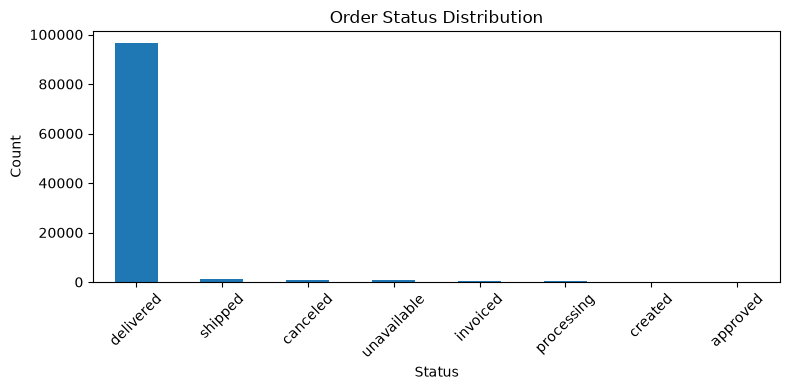

In [12]:
import matplotlib.pyplot as plt

orders["order_status"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)  


plt.tight_layout() 
plt.show()

In [13]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

<Axes: >

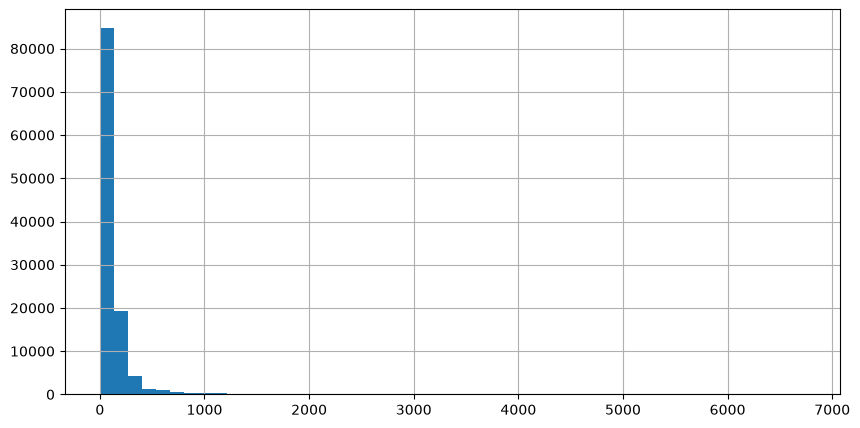

In [19]:
order_items["price"].hist(figsize=(10,5), bins=50)

C:\Users\Sandhya Sisodiya\AppData\Local\Temp\ipykernel_12896\1841985129.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(order_items["price"], vert=False)


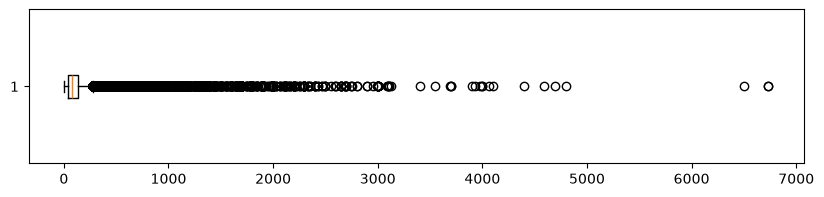

In [20]:
plt.figure(figsize=(10,2))

plt.boxplot(order_items["price"], vert=False)

plt.show()

In [21]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [22]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [23]:
orders["order_purchase_timestamp"]=pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [29]:
orders["order_purchase_timestamp"].min()


Timestamp('2016-09-04 21:15:19')

In [27]:
orders["order_purchase_timestamp"].max()

Timestamp('2018-10-17 17:30:18')

<Axes: xlabel='order_purchase_timestamp'>

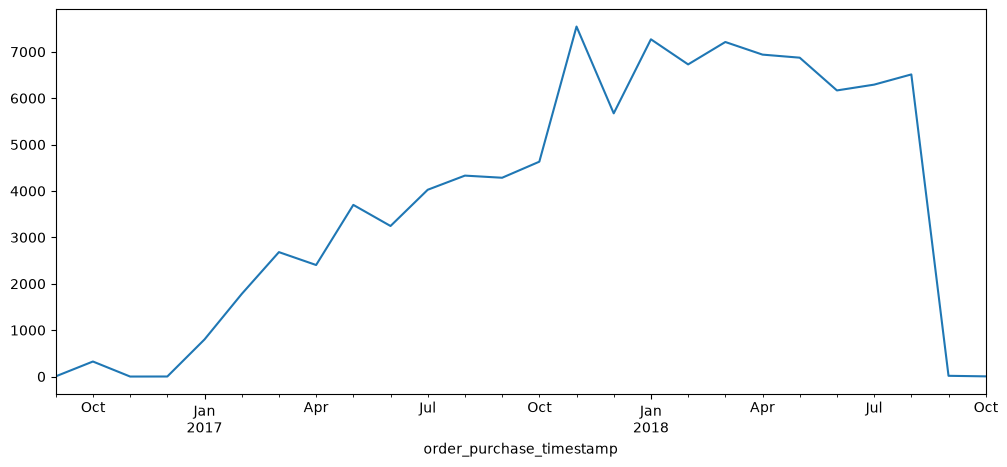

In [30]:
orders.set_index("order_purchase_timestamp") \
      .resample("MS") \
      .size() \
      .plot(figsize=(12,5))

In [31]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [32]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [34]:
orders[date_cols].describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


<Axes: title={'center': 'Monthly Orders'}, xlabel='order_purchase_timestamp'>

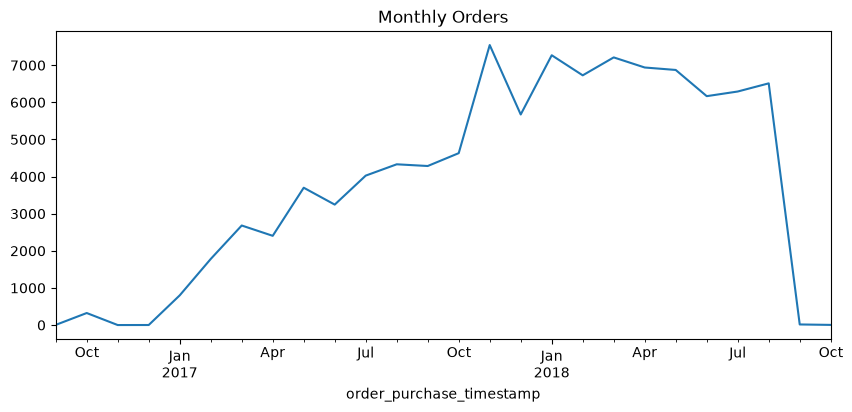

In [36]:
monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .size()
)
monthly_orders.plot(
    figsize=(10,4),
    title="Monthly Orders"
)

In [37]:
orders["year"] = orders["order_purchase_timestamp"].dt.year

orders["year"].value_counts().sort_index()

year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

In [38]:
orders["month"] = orders["order_purchase_timestamp"].dt.month_name()

orders["month"].value_counts()

month
August       10843
May          10573
July         10318
March         9893
June          9412
April         9343
February      8508
January       8069
November      7544
December      5674
October       4959
September     4305
Name: count, dtype: int64

In [39]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    -
    orders["order_purchase_timestamp"]
).dt.days
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [40]:
orders["late_delivery"] = (
    orders["order_delivered_customer_date"]
    >
    orders["order_estimated_delivery_date"]
)

orders["late_delivery"].value_counts()

late_delivery
False    91614
True      7827
Name: count, dtype: int64

In [41]:
orders["late_delivery"].value_counts(normalize=True)*100

late_delivery
False    92.129001
True      7.870999
Name: proportion, dtype: float64

In [42]:
core = (order_items.merge(orders,on="order_id",how="left")
    .merge(products, on="product_id", how="left" )
    .merge(customers, on="customer_id",how="left")
    .merge(category_translation, on="product_category_name",how="left"))
print(core.shape)

(112650, 31)


In [43]:
print("Order Items:", len(order_items))
print("Core:", len(core))

Order Items: 112650
Core: 112650


In [44]:
core["product_category_name_english"].value_counts().head(20)

product_category_name_english
bed_bath_table              11115
health_beauty                9670
sports_leisure               8641
furniture_decor              8334
computers_accessories        7827
housewares                   6964
watches_gifts                5991
telephony                    4545
garden_tools                 4347
auto                         4235
toys                         4117
cool_stuff                   3796
perfumery                    3419
baby                         3065
electronics                  2767
stationery                   2517
fashion_bags_accessories     2031
pet_shop                     1947
office_furniture             1691
consoles_games               1137
Name: count, dtype: int64

<Axes: xlabel='product_category_name_english'>

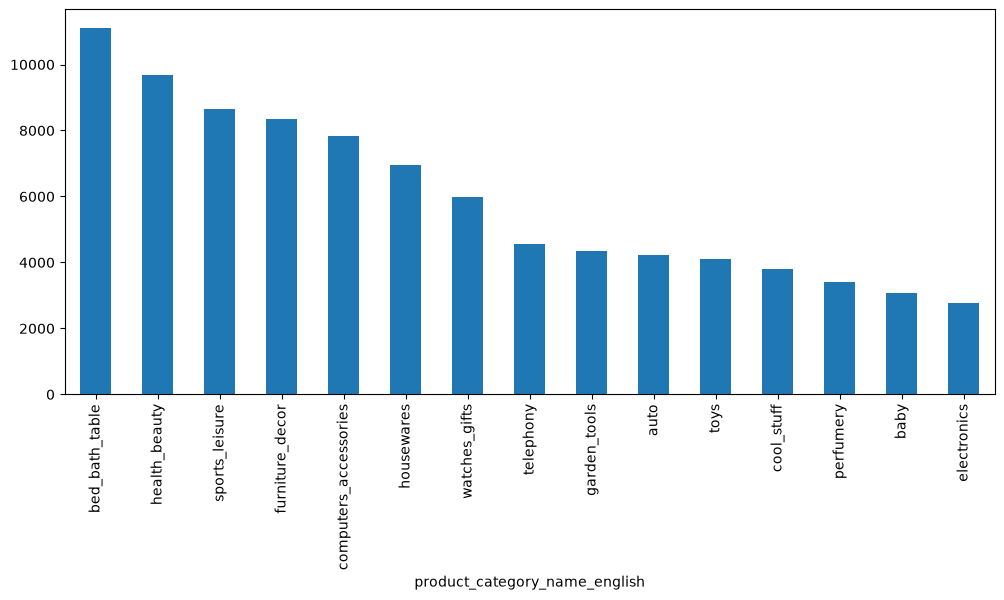

In [45]:
core["product_category_name_english"]\
    .value_counts()\
    .head(15)\
    .plot(
        kind="bar",
        figsize=(12,5)
    )

In [46]:
price_category = (core.groupby("product_category_name_english")["price"]
    .agg(["mean","median","min","max","count"])
    .sort_values("count",ascending=False))

price_category.head(20)

,mean,median,min,max,count
product_category_name_english,,,,,
bed_bath_table,93.296327,79.05,6.99,1999.98,11115
health_beauty,130.163531,79.90,1.20,3124.00,9670
sports_leisure,114.344285,78.00,4.50,4059.00,8641
furniture_decor,87.564494,65.49,4.90,1899.00,8334
computers_accessories,116.513903,81.99,3.90,3699.99,7827
housewares,90.788148,59.80,3.06,6735.00,6964
watches_gifts,201.135984,129.00,8.99,3999.90,5991
telephony,71.213978,29.99,5.00,2428.00,4545
garden_tools,111.630196,59.90,6.35,3930.00,4347


In [47]:
category_revenue = (core.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False))

category_revenue.head(15)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
toys                      483946.60
baby                      411764.89
perfumery                 399124.87
telephony                 323667.53
office_furniture          273960.70
Name: price, dtype: float64

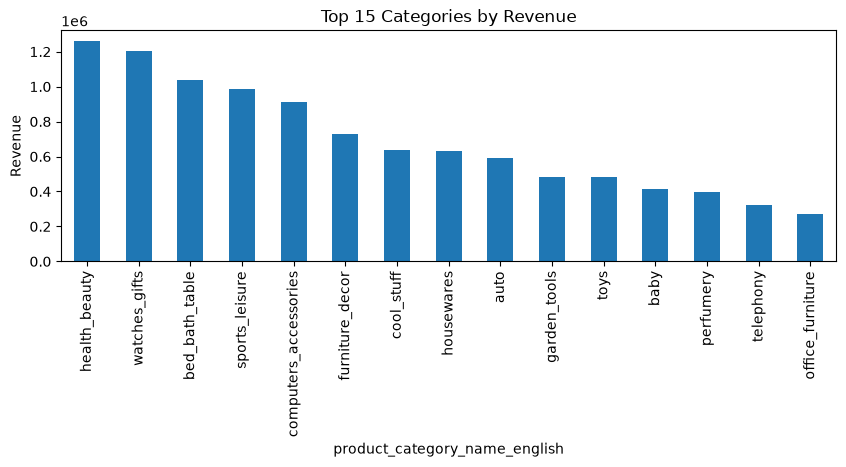

In [49]:
import matplotlib.pyplot as plt
category_revenue.head(15).plot(kind="bar",figsize=(10,3))
plt.title("Top 15 Categories by Revenue")
plt.ylabel("Revenue")
plt.show()

In [50]:
price_category.sort_values("mean",ascending=False).head(15)

,mean,median,min,max,count
product_category_name_english,,,,,
computers,1098.340542,1100.000,34.50,6729.00,203
small_appliances_home_oven_and_coffee,624.285658,587.000,10.19,2899.00,76
home_appliances_2,476.124958,225.945,13.90,2350.00,238
agro_industry_and_commerce,342.124858,258.650,12.99,2990.00,212
musical_instruments,281.616000,94.835,4.90,4399.87,680
small_appliances,280.778468,99.000,6.50,4799.00,679
fixed_telephony,225.693182,64.485,6.00,1790.00,264
construction_tools_safety,208.992371,125.575,8.90,3099.90,194
watches_gifts,201.135984,129.000,8.99,3999.90,5991


In [51]:
price_category.sort_values("median",ascending=False).head(15)

,mean,median,min,max,count
product_category_name_english,,,,,
computers,1098.340542,1100.000,34.50,6729.00,203
small_appliances_home_oven_and_coffee,624.285658,587.000,10.19,2899.00,76
agro_industry_and_commerce,342.124858,258.650,12.99,2990.00,212
home_appliances_2,476.124958,225.945,13.90,2350.00,238
furniture_bedroom,183.750275,179.000,6.90,650.00,109
office_furniture,162.011059,144.990,25.00,1189.90,1691
security_and_services,141.645000,141.645,100.00,183.29,2
air_conditioning,185.269226,139.990,10.90,1599.00,297
la_cuisine,146.785000,137.000,24.00,389.00,14


In [52]:
order_items["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

<Axes: >

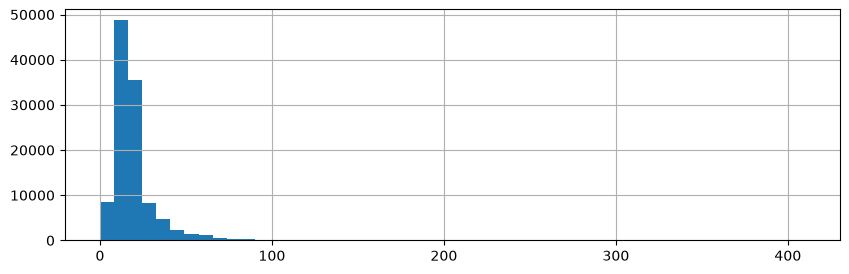

In [54]:
order_items["freight_value"].hist( bins=50, figsize=(10,3))

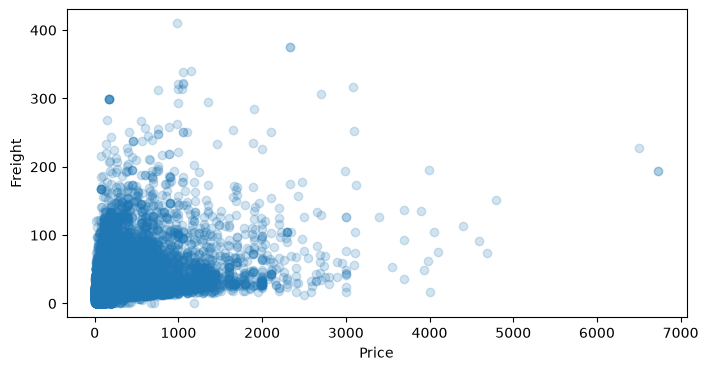

In [56]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.scatter(order_items["price"],order_items["freight_value"],alpha=0.2)

plt.xlabel("Price")
plt.ylabel("Freight")
plt.show()

In [57]:
order_items[["price","freight_value"]].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


<Axes: xlabel='order_purchase_timestamp'>

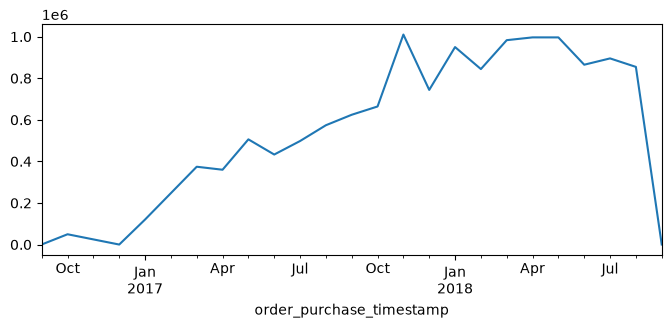

In [59]:
monthly_sales = (core.groupby(core["order_purchase_timestamp"].dt.to_period("M"))["price"].sum())
monthly_sales.plot(figsize=(8,3))

In [ ]:
category_delivery = (core.groupby("product_category_name_english")["delivery_days"].mean().sort_values())
category_delivery.head(15)

product_category_name_english
arts_and_craftmanship                     5.291667
la_cuisine                                7.071429
books_imported                            7.666667
fashion_childrens_clothes                 8.142857
party_supplies                            8.904762
food                                      9.100200
construction_tools_lights                 9.245847
small_appliances_home_oven_and_coffee     9.397260
signaling_and_security                    9.969543
drinks                                   10.019391
cine_photo                               10.128571
luggage_accessories                      10.194058
books_technical                          10.231939
diapers_and_hygiene                      10.243243
construction_tools_construction          10.288210
Name: delivery_days, dtype: float64

In [62]:
category_delivery.tail(15)

product_category_name_english
computers_accessories                12.779799
audio                                12.883978
home_confort                         13.039627
computers                            13.050251
consoles_games                       13.144169
garden_tools                         13.231959
fashion_underwear_beach              13.275591
furniture_living_room                13.294949
home_appliances_2                    13.424242
furniture_mattress_and_upholstery    13.891892
home_comfort_2                       14.066667
fashion_shoes                        14.933852
security_and_services                15.000000
christmas_supplies                   15.300000
office_furniture                     20.386691
Name: delivery_days, dtype: float64

In [63]:
core["customer_state"].value_counts()

customer_state
SP    47449
RJ    14579
MG    13129
RS     6235
PR     5740
SC     4176
BA     3799
DF     2406
GO     2333
ES     2256
PE     1806
CE     1478
PA     1080
MT     1055
MA      824
MS      819
PB      602
PI      542
RN      529
AL      444
SE      385
TO      315
RO      278
AM      165
AC       92
AP       82
RR       52
Name: count, dtype: int64

<Axes: xlabel='customer_state'>

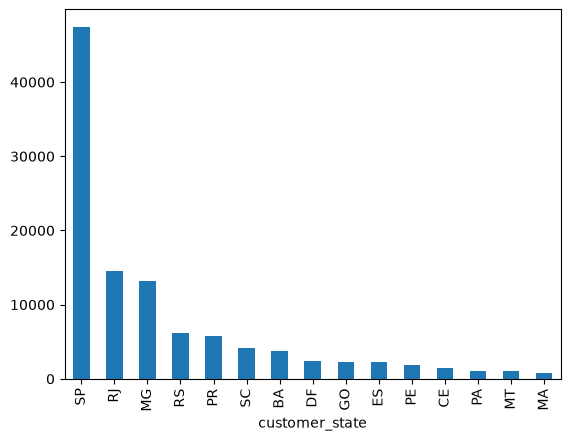

In [64]:
core["customer_state"].value_counts().head(15).plot(kind="bar")

In [65]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [66]:
payments.groupby("payment_type")["payment_value"].mean()

payment_type
boleto         145.034435
credit_card    163.319021
debit_card     142.570170
not_defined      0.000000
voucher         65.703354
Name: payment_value, dtype: float64

In [67]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

<Axes: xlabel='review_score'>

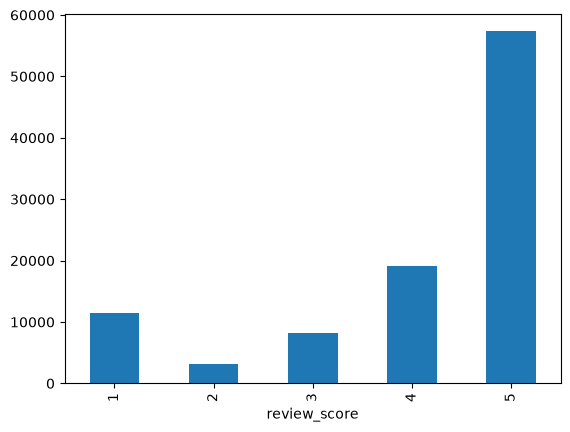

In [68]:
reviews["review_score"].value_counts().sort_index().plot(kind="bar")

In [69]:
review_core = (orders.merge(reviews,on="order_id"))

review_core["delivery_days"] = (review_core["order_delivered_customer_date"] - review_core["order_purchase_timestamp"]
).dt.days

In [70]:
review_core.groupby("review_score")["delivery_days"].mean()

review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_days, dtype: float64

In [71]:
customers["customer_unique_id"].nunique()

96096

In [72]:
customer_orders = (core.groupby("customer_unique_id").size())

In [76]:
customer_orders.value_counts().head(20)

1     83551
2      8996
3      1672
4       632
5       254
6       198
7        46
8        16
10       11
9        11
11       11
12        9
14        3
15        2
20        2
13        2
18        1
21        1
16        1
24        1
Name: count, dtype: int64

In [77]:
core["product_category_name"].isnull().sum()

np.int64(1603)

In [78]:
core[ core["product_category_name"].isnull()].head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english
123,0046e1d57f4c07c8c92ab26be8c3dfc0,1,ff6caf9340512b8bf6d2a2a6df032cfa,38e6dada03429a47197d5d584d793b41,2017-10-02 15:49:17,7.79,7.78,ae55e228ded796581eccc67045516023,delivered,2017-09-26 15:24:03,...,NaN,200.0,16.0,5.0,12.0,b0efd7adeb04d15b16edaedd11215d40,2712,sao paulo,SP,NaN
125,00482f2670787292280e0a8153d82467,1,a9c404971d1a5b1cbc2e4070e02731fd,702835e4b785b67a084280efca355756,2017-02-17 16:18:07,7.60,10.96,baa4ed05f22ffb6c4a41b71b699a492c,delivered,2017-02-13 16:18:07,...,NaN,700.0,35.0,14.0,11.0,d4c784ecad19dfe09e63ffaf9ada82a3,36050,juiz de fora,MG,NaN
132,004f5d8f238e8908e6864b874eda3391,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2018-03-06 09:29:25,122.99,15.61,a69c820c317aa348d781a9d6732afc23,delivered,2018-02-27 12:16:30,...,NaN,400.0,20.0,12.0,15.0,17726716a98c98a7806b43a789820245,79304,corumba,MS,NaN
142,0057199db02d1a5ef41bacbf41f8f63b,1,41eee23c25f7a574dfaf8d5c151dbb12,e5a3438891c0bfdb9394643f95273d8e,2018-01-25 09:07:51,20.30,16.79,c664dc5de5b5f4184bc4ca0285b9f8fe,delivered,2018-01-18 17:05:30,...,NaN,200.0,16.0,2.0,11.0,9a5b186787a143669398bd8083720c21,78550,sinop,MT,NaN
171,006cb7cafc99b29548d4f412c7f9f493,1,e10758160da97891c2fdcbc35f0f031d,323ce52b5b81df2cd804b017b7f09aa7,2018-02-22 13:35:28,56.00,14.14,97dc92f1aae3a7db8b252d1b8466910e,delivered,2018-02-17 14:22:34,...,NaN,2200.0,16.0,2.0,11.0,d5faae3f913e775994e53068992969b5,70670,brasilia,DF,NaN


In [79]:
core.nlargest( 20,"price")[
["product_category_name_english","price"]]

,product_category_name_english,price
3556,housewares,6735.00
112233,computers,6729.00
107841,art,6499.00
74336,small_appliances,4799.00
11249,small_appliances,4690.00
62086,computers,4590.00
29193,musical_instruments,4399.87
45843,consoles_games,4099.99
78310,sports_leisure,4059.00
59137,watches_gifts,3999.90


In [80]:
core["product_category_name_english"] = (core["product_category_name_english"].fillna("Unknown"))

In [81]:
state_revenue = (core.groupby("customer_state")["price"].sum().sort_values(ascending=False))
state_revenue.head(10)

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64

<Axes: title={'center': 'Top States by Revenue'}, xlabel='customer_state'>

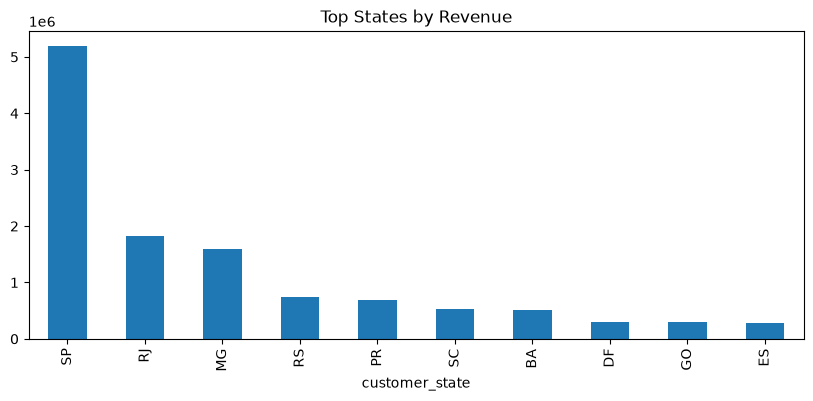

In [82]:
state_revenue.head(10).plot( kind="bar",figsize=(10,4), title="Top States by Revenue"
)

In [ ]:
city_revenue = (core.groupby("customer_city")["price"].sum().sort_values(ascending=False))
city_revenue.head(20)

customer_city
sao paulo                1914924.54
rio de janeiro            992538.86
belo horizonte            355611.13
brasilia                  301920.25
curitiba                  211738.06
porto alegre              190562.08
campinas                  187844.53
salvador                  181104.42
guarulhos                 144268.39
niteroi                   117907.12
goiania                   106111.17
sao bernardo do campo     104540.99
santos                     98777.09
fortaleza                  97868.06
santo andre                92083.50
recife                     89803.01
florianopolis              85925.99
osasco                     82157.86
jundiai                    81310.30
belem                      80977.48
Name: price, dtype: float64

In [84]:
seller_core = (core.merge( sellers, on="seller_id", how="left", suffixes=("","_seller")))

In [85]:
seller_sales = ( seller_core.groupby("seller_id")["price"].sum().sort_values(ascending=False))
seller_sales.head(20)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
46dc3b2cc0980fb8ec44634e21d2718e    128111.19
6560211a19b47992c3666cc44a7e94c0    123304.83
620c87c171fb2a6dd6e8bb4dec959fc6    114774.50
7d13fca15225358621be4086e1eb0964    113628.97
5dceca129747e92ff8ef7a997dc4f8ca    112155.53
1f50f920176fa81dab994f9023523100    106939.21
cc419e0650a3c5ba77189a1882b7556a    104288.42
a1043bafd471dff536d0c462352beb48    101901.16
3d871de0142ce09b7081e2b9d1733cb1     94914.20
edb1ef5e36e0c8cd84eb3c9b003e486d     79284.55
Name: price, dtype: float64

In [86]:
seller_core["seller_state"].value_counts()

seller_state
SP    80342
MG     8827
PR     8671
RJ     4818
SC     4075
RS     2199
DF      899
BA      643
GO      520
PE      448
MA      405
ES      372
MT      145
CE       94
RN       56
MS       50
PB       38
RO       14
PI       12
SE       10
PA        8
AM        3
AC        1
Name: count, dtype: int64

In [87]:
seller_core.groupby("seller_state")["price"].sum()

seller_state
AC        267.00
AM       1177.00
BA     285561.56
CE      20240.64
DF      97749.48
ES      47689.61
GO      66399.21
MA      36408.95
MG    1011564.74
MS       8551.69
MT      17070.72
PA       1238.00
PB      17095.00
PE      91493.85
PI       2522.00
PR    1261887.21
RJ     843984.22
RN       9992.60
RO       4762.20
RS     378559.54
SC     632426.07
SE       1606.20
SP    8753396.21
Name: price, dtype: float64

In [88]:
payments.groupby("payment_type")["payment_value"].sum()

payment_type
boleto          2869361.27
credit_card    12542084.19
debit_card       217989.79
not_defined           0.00
voucher          379436.87
Name: payment_value, dtype: float64

In [89]:
payments.groupby("payment_type")["payment_installments"].mean()

payment_type
boleto         1.000000
credit_card    3.507155
debit_card     1.000000
not_defined    1.000000
voucher        1.000000
Name: payment_installments, dtype: float64

In [90]:
payments["payment_installments"].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

<Axes: xlabel='payment_installments'>

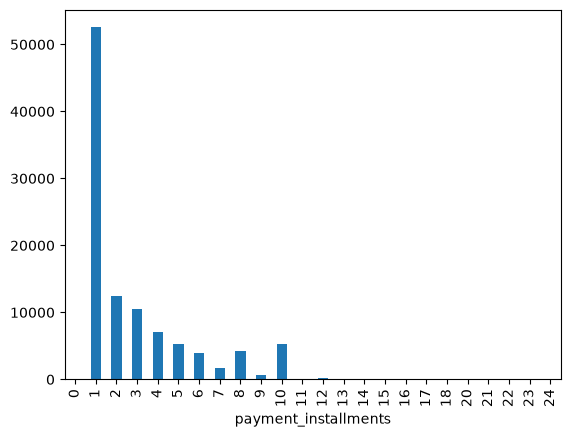

In [91]:
payments["payment_installments"].value_counts().sort_index().plot(kind="bar")

In [92]:
status_revenue = (core.groupby("order_status")["price"].sum())
status_revenue

order_status
approved            209.60
canceled          95235.27
delivered      13221498.11
invoiced          61526.37
processing        60439.22
shipped          150727.44
unavailable        2007.69
Name: price, dtype: float64

In [94]:
core.groupby("order_status")["delivery_days"].mean()

order_status
approved             NaN
canceled       18.000000
delivered      12.007342
invoiced             NaN
processing           NaN
shipped              NaN
unavailable          NaN
Name: delivery_days, dtype: float64

<Axes: xlabel='order_purchase_timestamp'>

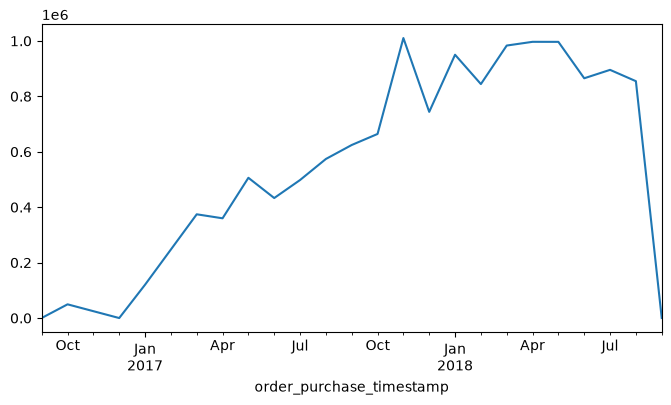

In [96]:
monthly_revenue = (core.groupby(core["order_purchase_timestamp"].dt.to_period("M"))["price"].sum())
monthly_revenue.plot(figsize=(8,4))

<Axes: xlabel='order_purchase_timestamp'>

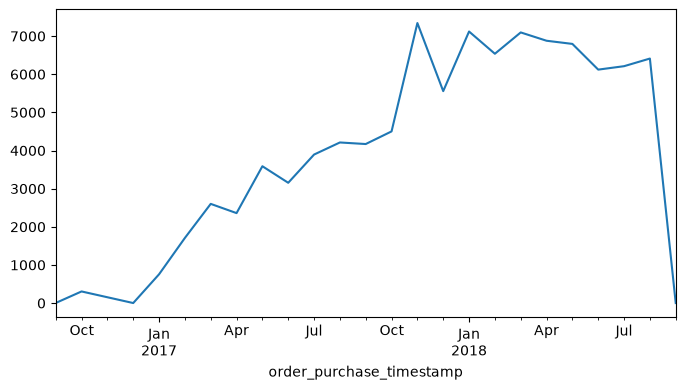

In [98]:
monthly_customers = (core.groupby( core["order_purchase_timestamp"].dt.to_period("M"))["customer_unique_id"].nunique())
monthly_customers.plot(figsize=(8,4))

In [99]:
order_value = (order_items.groupby("order_id")["price"].sum())
order_value.describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: price, dtype: float64

<Axes: >

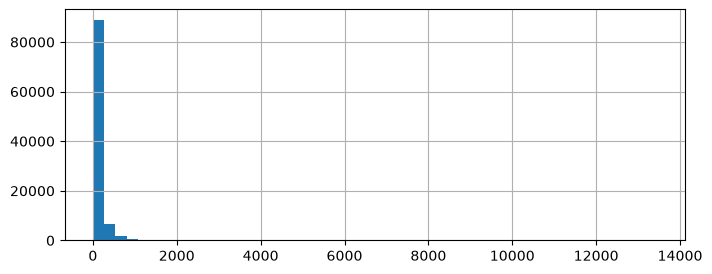

In [ ]:
order_value.hist(bins=50, figsize=(8,3))

In [102]:
order_items["freight_percent"] = (order_items["freight_value"] /order_items["price"])*100

In [103]:
order_items["freight_percent"].describe()

count    112650.000000
mean         32.086355
std          34.989368
min           0.000000
25%          13.403366
50%          23.135624
75%          39.303621
max        2623.529412
Name: freight_percent, dtype: float64

In [104]:
order_items.nlargest(20,"freight_percent"
)[["price","freight_value","freight_percent"]]

,price,freight_value,freight_percent
87081,0.85,22.30,2623.529412
27652,0.85,18.23,2144.705882
48625,0.85,18.23,2144.705882
110535,9.90,121.22,1224.444444
94495,4.99,37.04,742.284569
57297,1.20,7.89,657.500000
57298,1.20,7.89,657.500000
57299,1.20,7.89,657.500000
57300,1.20,7.89,657.500000
57301,1.20,7.89,657.500000


In [105]:
core["volume"] = (core["product_length_cm"]*core["product_height_cm"]*core["product_width_cm"])

In [106]:
core[["volume","freight_value"]].corr()

,volume,freight_value
volume,1.00000,0.58727
freight_value,0.58727,1.00000


In [107]:
core[["product_weight_g","freight_value"]].corr()

,product_weight_g,freight_value
product_weight_g,1.00000,0.61042
freight_value,0.61042,1.00000


In [108]:
review_core["late_delivery"] = (review_core["order_delivered_customer_date"]>review_core["order_estimated_delivery_date"])

In [109]:
review_core.groupby("late_delivery")["review_score"].mean()

late_delivery
False    4.214307
True     2.566550
Name: review_score, dtype: float64

In [110]:
review_category = (review_core.merge(order_items,on="order_id").merge(products,on="product_id").merge(category_translation,    
    on="product_category_name",    how="left"))

In [111]:
review_category.groupby("product_category_name_english"
)["review_score"].mean().sort_values()

product_category_name_english
security_and_services        2.500000
diapers_and_hygiene          3.256410
office_furniture             3.493183
home_comfort_2               3.629630
fashion_male_clothing        3.641221
                               ...   
flowers                      4.419355
costruction_tools_tools      4.444444
books_general_interest       4.446266
fashion_childrens_clothes    4.500000
cds_dvds_musicals            4.642857
Name: review_score, Length: 71, dtype: float64

In [112]:
numeric = core.select_dtypes(include="number")
numeric.corr()

,order_item_id,price,freight_value,year,delivery_days,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix,volume
order_item_id,1.000000,-0.060522,-0.029380,0.001198,-0.015729,-0.022662,-0.014311,-0.055852,-0.003549,0.005628,0.029323,-0.010732,-0.000874,0.004477
price,-0.060522,1.000000,0.414204,-0.002793,0.062290,0.017001,0.198166,0.051848,0.338819,0.145811,0.223602,0.172467,0.042467,0.298754
freight_value,-0.029380,0.414204,1.000000,0.033289,0.214631,0.023611,0.093855,0.022259,0.610420,0.309086,0.391831,0.323777,0.225690,0.587270
year,0.001198,-0.002793,0.033289,1.000000,-0.051380,0.021951,0.038900,-0.006303,-0.024794,-0.051915,-0.029117,-0.058431,-0.036819,-0.049343
delivery_days,-0.015729,0.062290,0.214631,-0.051380,1.000000,-0.003207,0.005280,-0.026778,0.085610,0.068717,0.066871,0.039302,0.272698,0.078019
product_name_lenght,-0.022662,0.017001,0.023611,0.021951,-0.003207,1.000000,0.091524,0.145904,0.022731,0.060447,-0.028170,0.064442,0.015515,0.020581
product_description_lenght,-0.014311,0.198166,0.093855,0.038900,0.005280,0.091524,1.000000,0.118087,0.059710,0.005971,0.072724,-0.068419,0.023709,0.018910
product_photos_qty,-0.055852,0.051848,0.022259,-0.006303,-0.026778,0.145904,0.118087,1.000000,0.022667,0.047503,-0.033399,0.010367,0.019626,0.012167
product_weight_g,-0.003549,0.338819,0.610420,-0.024794,0.085610,0.022731,0.059710,0.022667,1.000000,0.460919,0.583277,0.506609,0.003242,0.802267
product_length_cm,0.005628,0.145811,0.309086,-0.051915,0.068717,0.060447,0.005971,0.047503,0.460919,1.000000,0.192895,0.532537,0.007491,0.541464


In [ ]:
customer_spending = (core.groupby("customer_unique_id")["price"].sum().sort_values(ascending=False))

customer_spending.head(20)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.00
da122df9eeddfedc1dc1f5349a1a690c     7388.00
763c8b1c9c68a0229c42c9fc6f662b93     7160.00
dc4802a71eae9be1dd28f5d788ceb526     6735.00
459bef486812aa25204be022145caa62     6729.00
ff4159b92c40ebe40454e3e6a7c35ed6     6499.00
4007669dec559734d6f53e029e360987     5934.60
eebb5dda148d3893cdaf5b5ca3040ccb     4690.00
5d0a2980b292d049061542014e8960bf     4599.90
48e1ac109decbb87765a3eade6854098     4590.00
a229eba70ec1c2abef51f04987deb7a5     4400.00
edde2314c6c30e864a128ac95d6b2112     4399.87
fa562ef24d41361e476e748681810e1e     4099.99
c8460e4251689ba205045f3ea17884a1     4080.00
ca27f3dac28fb1063faddd424c9d95fa     4059.00
055ec572ac7f3c7bdd04a183830ebe59     3999.98
011875f0176909c5cf0b14a9138bb691     3999.90
edf81e1f3070b9dac83ec83dacdbb9bc     3999.00
5e713be0853d8986528d7869a0811d2b     3980.00
f0767ae738c3d90e7b737d7b8b8bb4d1     3930.00
Name: price, dtype: float64

<Axes: title={'center': 'Top Customers by Spending'}, xlabel='customer_unique_id'>

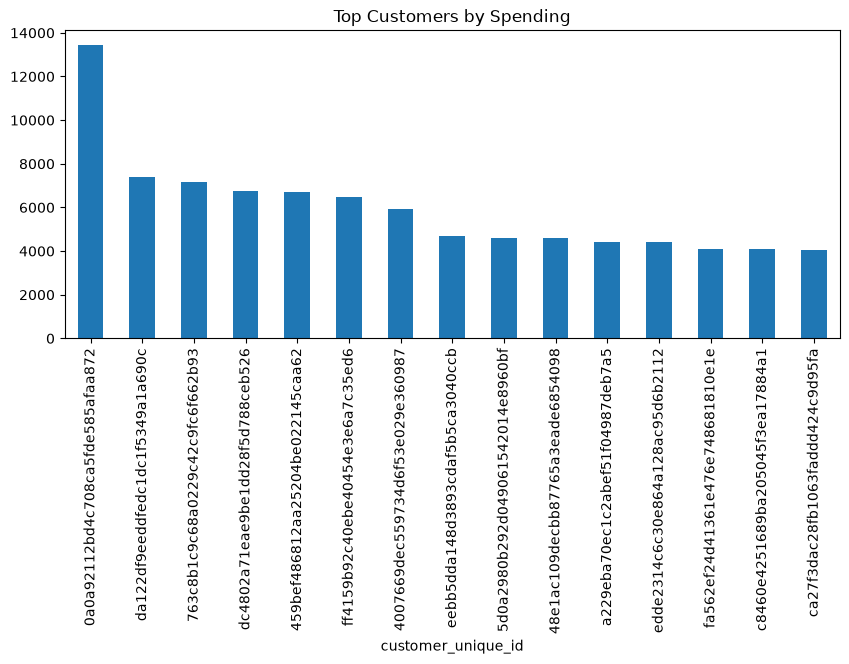

In [114]:
customer_spending.head(15).plot(kind="bar",figsize=(10,4),title="Top Customers by Spending")

In [ ]:
customer_orders = (core.groupby("customer_unique_id").order_id.nunique().sort_values(ascending=False))

customer_orders.head(20)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    16
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
63cfc61cee11cbe306bff5857d00bfe4     6
dc813062e0fc23409cd255f7f53c7074     6
f0e310a6839dce9de1638e0fe5ab282a     6
56c8638e7c058b98aae6d74d2dd6ea23     5
35ecdf6858edc6427223b64804cf028e     5
4e65032f1f574189fb793bac5a867bbc     5
5e8f38a9a1c023f3db718edcf926a2db     5
394ac4de8f3acb14253c177f0e15bc58     5
b4e4f24de1e8725b74e4a1f4975116ed     5
74cb1ad7e6d5674325c1f99b5ea30d82     5
de34b16117594161a6a89c50b289d35a     5
fe81bb32c243a86b2f86fbf053fe6140     5
83e7958a94bd7f74a9414d8782f87628     4
Name: order_id, dtype: int64

In [ ]:
monthly_year = (core.groupby([core["order_purchase_timestamp"].dt.year,core["order_purchase_timestamp"].dt.month
])["price"].sum())

monthly_year

order_purchase_timestamp  order_purchase_timestamp
2016                      9                               267.36
                          10                            49507.66
                          12                               10.90
2017                      1                            120312.87
                          2                            247303.02
                          3                            374344.30
                          4                            359927.23
                          5                            506071.14
                          6                            433038.60
                          7                            498031.48
                          8                            573971.68
                          9                            624401.69
                          10                           664219.43
                          11                          1010271.37
                          12           

In [118]:
order_value = (order_items.groupby("order_id")["price"].sum())
AOV = order_value.mean()
print(AOV)

137.75407637889444


In [119]:
category_percent = (category_revenue /category_revenue.sum())*100
category_percent.head(20)

product_category_name_english
health_beauty            9.388524
watches_gifts            8.988157
bed_bath_table           7.734915
sports_leisure           7.369873
computers_accessories    6.802282
furniture_decor          5.443310
cool_stuff               4.738645
housewares               4.715953
auto                     4.421109
garden_tools             3.619536
toys                     3.609765
baby                     3.071361
perfumery                2.977079
telephony                2.414241
office_furniture         2.043477
stationery               1.722609
computers                1.663086
pet_shop                 1.598582
musical_instruments      1.428393
small_appliances         1.422051
Name: price, dtype: float64

In [120]:
cum = category_percent.cumsum()
cum.head(20)

product_category_name_english
health_beauty             9.388524
watches_gifts            18.376681
bed_bath_table           26.111596
sports_leisure           33.481470
computers_accessories    40.283752
furniture_decor          45.727062
cool_stuff               50.465706
housewares               55.181659
auto                     59.602768
garden_tools             63.222304
toys                     66.832069
baby                     69.903430
perfumery                72.880509
telephony                75.294750
office_furniture         77.338228
stationery               79.060837
computers                80.723923
pet_shop                 82.322505
musical_instruments      83.750898
small_appliances         85.172949
Name: price, dtype: float64

In [121]:
state_delivery = ( core.groupby("customer_state")["delivery_days"] .mean() .sort_values())
state_delivery

customer_state
SP     8.259609
PR    11.480793
MG    11.515522
DF    12.501486
SC    14.520986
RJ    14.689382
RS    14.708299
GO    14.948177
MS    15.107275
ES    15.192809
TO    17.003226
MT    17.508197
PE    17.792096
BA    18.774640
RN    18.873321
PI    18.931166
RO    19.282051
PB    20.119454
AC    20.329670
CE    20.537167
SE    20.978667
MA    21.203750
PA    23.301708
AL    23.992974
AM    25.963190
AP    27.753086
RR    27.826087
Name: delivery_days, dtype: float64

In [122]:
cancelled = (core.query("order_status=='canceled'")["price"].sum())

cancelled

np.float64(95235.26999999999)

In [123]:
unavailable = (core.query("order_status=='unavailable'")["price"].sum())
unavailable

np.float64(2007.69)

In [124]:
shipped = (core.query("order_status=='shipped'")["price"].sum())
shipped

np.float64(150727.44)

In [125]:
processing = (core.query("order_status=='processing'")["price"].sum())
processing

np.float64(60439.22)

In [127]:
category_freight = (core.groupby("product_category_name_english")["freight_value"].mean())
print(category_freight)

product_category_name_english
Unknown                       17.586441
agro_industry_and_commerce    27.564151
air_conditioning              22.724680
art                           19.354880
arts_and_craftmanship         15.422083
                                ...    
stationery                    18.592960
tablets_printing_image        14.773494
telephony                     15.669041
toys                          18.806400
watches_gifts                 16.781160
Name: freight_value, Length: 72, dtype: float64


In [128]:
repeat = (core.groupby("customer_unique_id").filter(lambda x: len(x)>1))
repeat["price"].sum()

np.float64(2601359.48)

In [129]:
core.groupby("customer_state")["late_delivery"].mean()*100

customer_state
AC     3.260870
AL    23.198198
AM     4.242424
AP     4.878049
BA    13.266649
CE    14.749662
DF     7.273483
ES    12.056738
GO     7.672525
MA    19.781553
MG     5.362175
MS    10.744811
MT     6.635071
PA    12.129630
PB    10.963455
PE     9.856035
PI    14.944649
PR     4.703833
RJ    12.586597
RN    10.207940
RO     3.956835
RR     9.615385
RS     6.768244
SC     9.434866
SE    15.844156
SP     5.646062
TO    12.063492
Name: late_delivery, dtype: float64

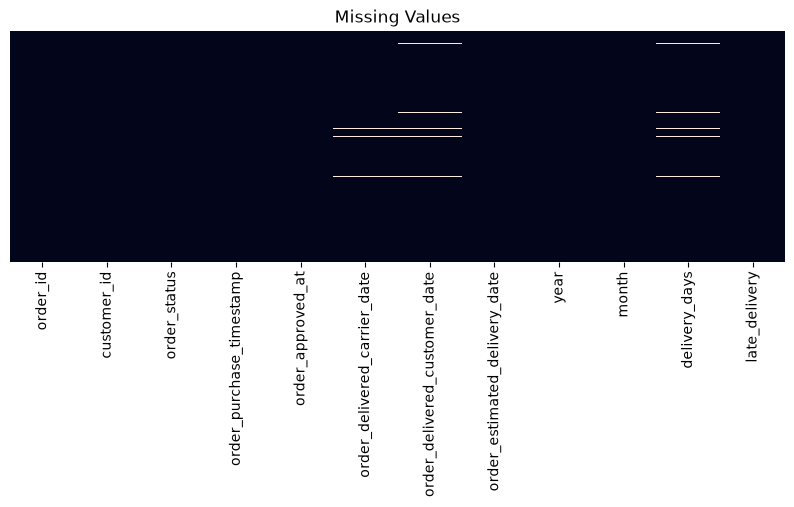

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
sns.heatmap(orders.isnull(),cbar=False,yticklabels=False)
plt.title("Missing Values")
plt.show()

In [134]:
print(core["price"].skew())
print(core["freight_value"].skew())
print(core["delivery_days"].skew())

7.9232082632135095
5.639869620428685
3.8343410555858717


In [135]:
(core.isnull().mean()*100).sort_values(ascending=False)

order_delivered_customer_date    2.178429
delivery_days                    2.178429
product_category_name            1.422992
product_name_lenght              1.422992
product_description_lenght       1.422992
product_photos_qty               1.422992
order_delivered_carrier_date     1.059920
product_weight_g                 0.015979
product_height_cm                0.015979
product_length_cm                0.015979
product_width_cm                 0.015979
volume                           0.015979
order_approved_at                0.013316
order_item_id                    0.000000
shipping_limit_date              0.000000
order_id                         0.000000
month                            0.000000
year                             0.000000
order_estimated_delivery_date    0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
price                            0.000000
freight_value                    0.000000
customer_id                      0

In [136]:
(core["order_delivered_customer_date"]<core["order_purchase_timestamp"]).sum()

np.int64(0)

In [137]:
(core["order_approved_at"]<core["order_purchase_timestamp"]).sum()

np.int64(0)

In [138]:
(core["order_delivered_carrier_date"]<core["order_approved_at"]).sum()

np.int64(1551)

In [140]:
print(core["price"].sum())
print(order_items["price"].sum())

13591643.7
13591643.7
